# Simplified VQE Notebook

Levi Brunelle 20899737

Matthew Athansopoulos

Oscar McCormack



This notebook is a compact version of the github repo. It doesnt have all the same features, but keeps the main ones:

1. single run  
2. repetitions / depth comparison  
3. optimizer comparison  
4. ansatz comparison  
5. noise comparison  


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error
from qiskit_algorithms import NumPyMinimumEigensolver, VQE
from qiskit_algorithms.optimizers import COBYLA, SPSA, GradientDescent
from qiskit_algorithms.utils import algorithm_globals
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120

/Users/levibrunelle/Desktop/Nano/4B/NE405C/Final-Project/NE405C-Final_Project-LiH_VQE/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Global settings

CONFIG = {
    "molecule_name": "LiH",      # "LiH" or "BeH2"
    "basis": "sto3g",
    "bond_length": 1.6,
    "charge": 0,
    "spin": 0,
    "random_seed": 123,

    # hardware-efficient defaults
    "reps": 2,
    "entanglement_pattern": "linear",

    # optimizer evaluation limits
    "cobyla_maxiter": 200,
    "spsa_maxiter": 100,         # roughly half of COBYLA if you want roughly matched evaluation number
    "gd_maxiter": 12,
    "gd_learning_rate": 0.05,

    # Aer / noise settings
    "aer_default_precision": 5e-2,
    "noise_1q": 0.001,
    "noise_2q": 0.01,
    "readout_error": 0.02,
}

CONFIG

{'molecule_name': 'LiH',
 'basis': 'sto3g',
 'bond_length': 1.6,
 'charge': 0,
 'spin': 0,
 'random_seed': 123,
 'reps': 2,
 'entanglement_pattern': 'linear',
 'cobyla_maxiter': 200,
 'spsa_maxiter': 100,
 'gd_maxiter': 12,
 'gd_learning_rate': 0.05,
 'aer_default_precision': 0.05,
 'noise_1q': 0.001,
 'noise_2q': 0.01,
 'readout_error': 0.02}

In [3]:
def molecule_string(name: str, bond_length: float) -> str:
    if name == "LiH":
        return f"Li 0 0 0; H 0 0 {bond_length}"
    if name == "BeH2":
        return f"H 0 0 {-bond_length}; Be 0 0 0; H 0 0 {bond_length}"
    raise ValueError(f"Unsupported molecule: {name}")


def build_problem_bundle(config=CONFIG):
    driver = PySCFDriver(
        atom=molecule_string(config["molecule_name"], config["bond_length"]),
        basis=config["basis"],
        charge=config["charge"],
        spin=config["spin"],
        unit=DistanceUnit.ANGSTROM,
    )
    problem = driver.run()
    fermionic_hamiltonian = problem.hamiltonian.second_q_op()
    mapper = JordanWignerMapper()
    qubit_hamiltonian = mapper.map(fermionic_hamiltonian).simplify()
    return {
        "problem": problem,
        "fermionic_hamiltonian": fermionic_hamiltonian,
        "mapper": mapper,
        "qubit_hamiltonian": qubit_hamiltonian,
    }


def exact_energy(qubit_hamiltonian):
    solver = NumPyMinimumEigensolver()
    result = solver.compute_minimum_eigenvalue(qubit_hamiltonian)
    return float(result.eigenvalue.real)


def build_hardware_efficient_ansatz(num_qubits: int, reps: int, entanglement_pattern: str = "linear"):
    qc = QuantumCircuit(num_qubits)
    theta = ParameterVector("theta", reps * num_qubits * 2)
    k = 0

    for _ in range(reps):
        for q in range(num_qubits):
            qc.ry(theta[k], q)
            k += 1
        for q in range(num_qubits):
            qc.rz(theta[k], q)
            k += 1
        for q in range(num_qubits - 1):
            qc.cx(q, q + 1)
        if entanglement_pattern == "circular" and num_qubits > 2:
            qc.cx(num_qubits - 1, 0)

    return qc


def build_ansatz(bundle, ansatz_kind="hardware_efficient", reps=None, config=CONFIG):
    problem = bundle["problem"]
    mapper = bundle["mapper"]
    num_qubits = bundle["qubit_hamiltonian"].num_qubits

    if ansatz_kind == "hardware_efficient":
        reps = config["reps"] if reps is None else reps
        ansatz = build_hardware_efficient_ansatz(
            num_qubits=num_qubits,
            reps=reps,
            entanglement_pattern=config["entanglement_pattern"],
        )
        initial_point = np.zeros(ansatz.num_parameters, dtype=float)
        return ansatz, initial_point

    if ansatz_kind == "uccsd_hf":
        hf = HartreeFock(
            num_spatial_orbitals=problem.num_spatial_orbitals,
            num_particles=problem.num_particles,
            qubit_mapper=mapper,
        )
        ansatz = UCCSD(
            num_spatial_orbitals=problem.num_spatial_orbitals,
            num_particles=problem.num_particles,
            qubit_mapper=mapper,
            initial_state=hf,
        )
        initial_point = np.zeros(ansatz.num_parameters, dtype=float)
        return ansatz, initial_point

    raise ValueError(f"Unsupported ansatz_kind: {ansatz_kind}")


def build_optimizer(name="COBYLA", config=CONFIG):
    if name == "COBYLA":
        return COBYLA(maxiter=config["cobyla_maxiter"])
    if name == "SPSA":
        return SPSA(maxiter=config["spsa_maxiter"])
    if name == "GRADIENT_DESCENT":
        return GradientDescent(
            maxiter=config["gd_maxiter"],
            learning_rate=config["gd_learning_rate"],
        )
    raise ValueError(f"Unsupported optimizer: {name}")


def build_noise_model(config=CONFIG):
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(config["noise_1q"], 1),
        ["ry", "rz", "x"],
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(config["noise_2q"], 2),
        ["cx"],
    )
    readout = ReadoutError(
        [
            [1 - config["readout_error"], config["readout_error"]],
            [config["readout_error"], 1 - config["readout_error"]],
        ]
    )
    noise_model.add_all_qubit_readout_error(readout)
    return noise_model


def build_estimator(mode="statevector", config=CONFIG, seed=None):
    if mode == "statevector":
        return StatevectorEstimator()

    options = {
        "default_precision": config["aer_default_precision"],
        "backend_options": {
            "method": "automatic",
            "seed_simulator": seed,
        },
    }

    if mode == "aer_noise":
        options["backend_options"]["noise_model"] = build_noise_model(config)

    if mode not in {"aer_shots", "aer_noise"}:
        raise ValueError(f"Unsupported backend mode: {mode}")

    return AerEstimator(options=options)


def optimizer_eval_budget(name="COBYLA", config=CONFIG):
    if name == "COBYLA":
        return config["cobyla_maxiter"]
    if name == "SPSA":
        return config["spsa_maxiter"] * 2
    if name == "GRADIENT_DESCENT":
        return config["gd_maxiter"] * 50
    raise ValueError(f"Unsupported optimizer: {name}")


def run_vqe(
    bundle,
    *,
    ansatz_kind="hardware_efficient",
    optimizer_name="COBYLA",
    backend_mode="statevector",
    reps=None,
    seed=None,
    show_progress=True,
    label=None,
    config=CONFIG,
):
    if seed is not None:
        algorithm_globals.random_seed = seed
        np.random.seed(seed)

    ansatz, initial_point = build_ansatz(bundle, ansatz_kind=ansatz_kind, reps=reps, config=config)
    estimator = build_estimator(mode=backend_mode, config=config, seed=seed)
    optimizer = build_optimizer(name=optimizer_name, config=config)

    counts = []
    energies = []
    pbar = None
    last_eval = 0

    if show_progress:
        pbar = tqdm(
            total=optimizer_eval_budget(optimizer_name, config),
            desc=label or f"{backend_mode}:{optimizer_name}",
            leave=False,
        )

    def callback(eval_count, params, mean, metadata):
        nonlocal last_eval
        counts.append(int(eval_count))
        energies.append(float(mean))

        if pbar is not None:
            inc = max(0, int(eval_count) - last_eval)
            if inc:
                pbar.update(inc)
                last_eval = int(eval_count)
            pbar.set_postfix(best=f"{min(energies):.6f}")

    result = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer,
        initial_point=initial_point,
        callback=callback,
    ).compute_minimum_eigenvalue(bundle["qubit_hamiltonian"])

    if pbar is not None:
        pbar.close()

    e_exact = exact_energy(bundle["qubit_hamiltonian"])

    return {
        "energy": float(result.eigenvalue.real),
        "exact_energy": e_exact,
        "abs_error": abs(float(result.eigenvalue.real) - e_exact),
        "counts": counts,
        "energies": energies,
        "ansatz": ansatz,
        "ansatz_kind": ansatz_kind,
        "optimizer_name": optimizer_name,
        "backend_mode": backend_mode,
        "num_parameters": int(ansatz.num_parameters),
    }


def running_best(values):
    arr = np.array(values, dtype=float)
    return np.minimum.accumulate(arr)


def plot_overlay(results, title, ylabel="Energy (Hartree)", use_running_best=True):
    plt.figure(figsize=(8, 5))
    exact_drawn = False

    for label, result in results.items():
        x = np.array(result["counts"], dtype=float)
        y = running_best(result["energies"]) if use_running_best else np.array(result["energies"], dtype=float)
        plt.plot(x, y, linewidth=2, label=f"{label} (err={result['abs_error']:.4f} Ha)")
        if not exact_drawn:
            plt.axhline(result["exact_energy"], linestyle="--", linewidth=2, label="Exact energy")
            exact_drawn = True

    plt.xlabel("Evaluation count")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def print_summary(result):
    print(f"Energy:        {result['energy']:.10f} Ha")
    print(f"Exact energy:  {result['exact_energy']:.10f} Ha")
    print(f"Absolute error:{result['abs_error']:.10f} Ha")
    print(f"Parameters:    {result['num_parameters']}")


bundle = build_problem_bundle(CONFIG)
print("Qubits:", bundle["qubit_hamiltonian"].num_qubits)
print("Pauli terms:", len(bundle["qubit_hamiltonian"]))
print("Exact energy:", exact_energy(bundle["qubit_hamiltonian"]))

Qubits: 12
Pauli terms: 631
Exact energy: -8.87453164935849


## 1. Single run

One VQE run for the current molecule and settings.

Energy:        -7.8388794049 Ha
Exact energy:  -8.8745316494 Ha
Absolute error:1.0356522445 Ha
Parameters:    48


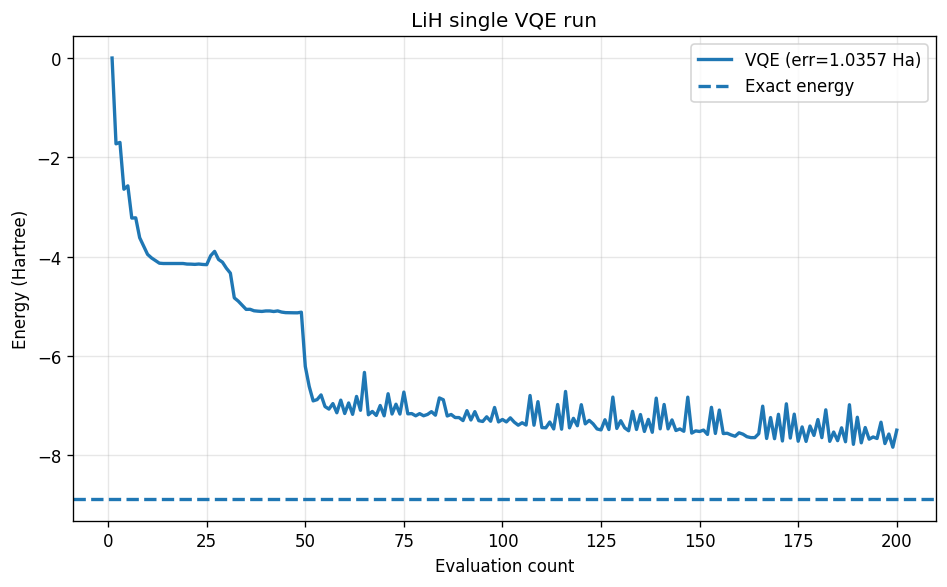

In [4]:
single = run_vqe(
    bundle,
    ansatz_kind="hardware_efficient",
    optimizer_name="COBYLA",
    backend_mode="statevector",
    reps=CONFIG["reps"],
    seed=CONFIG["random_seed"],
    show_progress=True,
    label="single_run",
)

print_summary(single)
plot_overlay(
    {"VQE": single},
    title=f"{CONFIG['molecule_name']} single VQE run",
    use_running_best=False,
)

## 2. Repetitions / depth comparison

Compare hardware-efficient ansätze with different repetition counts.

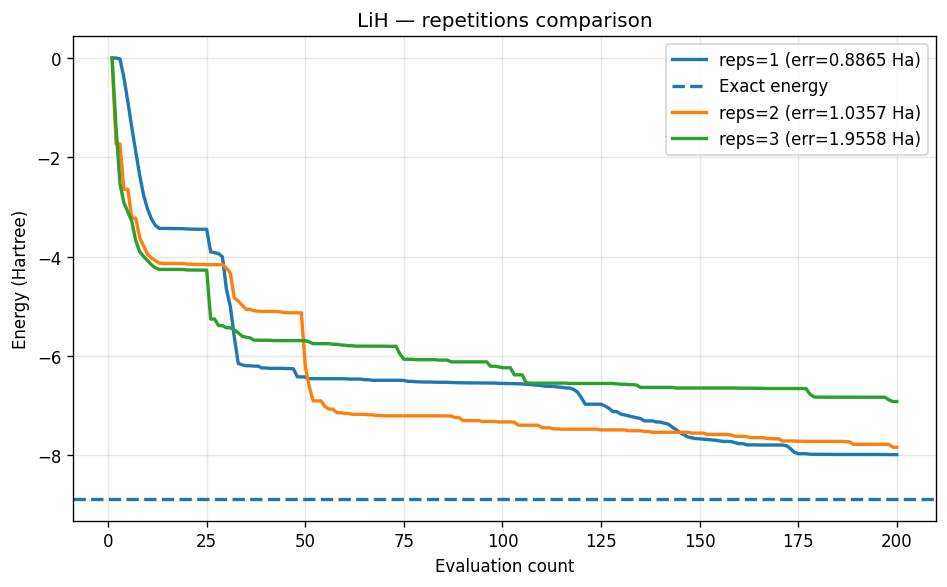

In [5]:
reps_values = [1, 2, 3]

reps_results = {
    f"reps={r}": run_vqe(
        bundle,
        ansatz_kind="hardware_efficient",
        optimizer_name="COBYLA",
        backend_mode="statevector",
        reps=r,
        seed=CONFIG["random_seed"],
        show_progress=True,
        label=f"reps={r}",
    )
    for r in reps_values
}

plot_overlay(
    reps_results,
    title=f"{CONFIG['molecule_name']} — repetitions comparison",
)

## 3. Optimizer comparison

Compare COBYLA and SPSA on the same problem and ansatz.

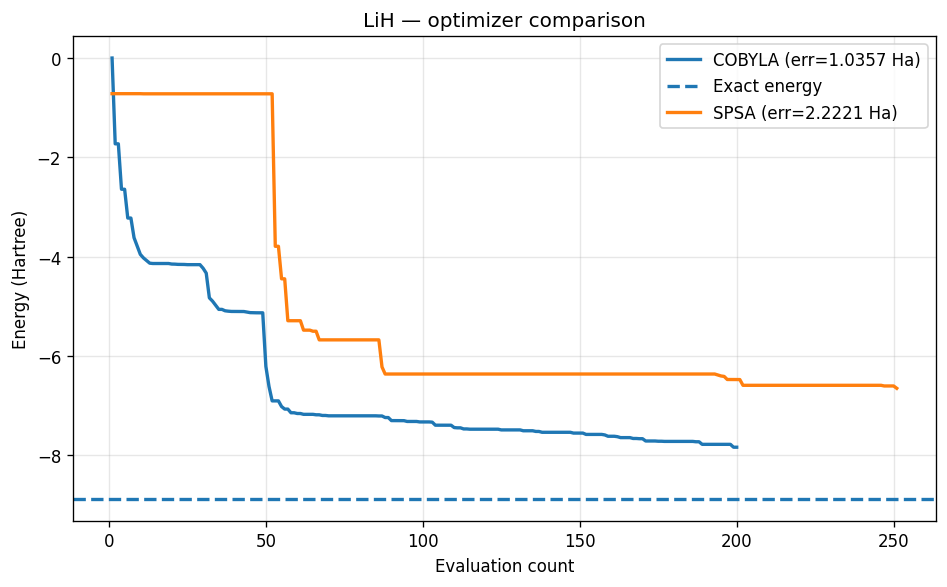

In [6]:
optimizer_results = {
    name: run_vqe(
        bundle,
        ansatz_kind="hardware_efficient",
        optimizer_name=name,
        backend_mode="statevector",
        reps=CONFIG["reps"],
        seed=CONFIG["random_seed"],
        show_progress=True,
        label=name,
    )
    for name in ["COBYLA", "SPSA"]
}

plot_overlay(
    optimizer_results,
    title=f"{CONFIG['molecule_name']} — optimizer comparison",
)

## 4. Ansatz comparison

Compare the generic hardware-efficient ansatz against UCCSD + Hartree–Fock.

Note: UCCSD can look unusual in convergence because it often starts very close to the exact energy for small molecules.

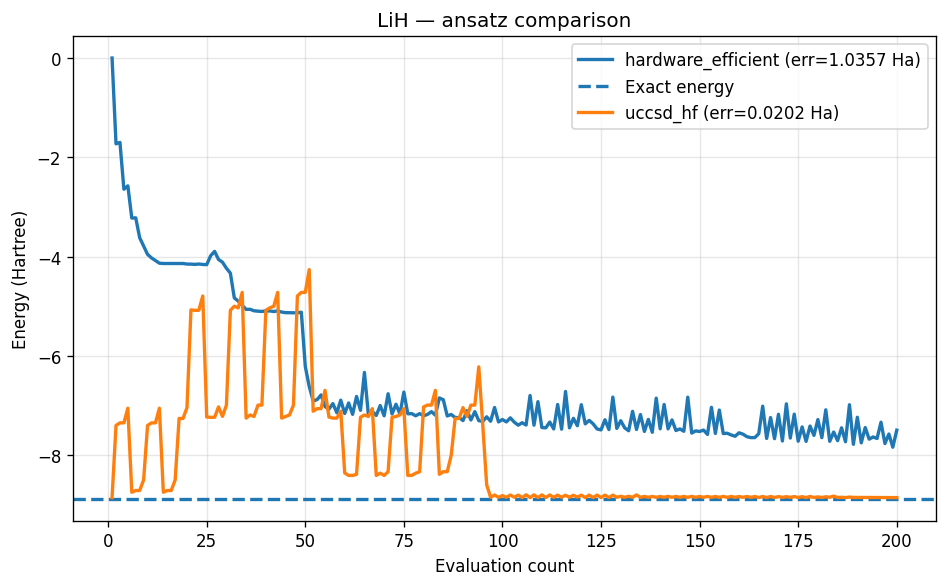

In [7]:
ansatz_results = {
    "hardware_efficient": run_vqe(
        bundle,
        ansatz_kind="hardware_efficient",
        optimizer_name="COBYLA",
        backend_mode="statevector",
        reps=CONFIG["reps"],
        seed=CONFIG["random_seed"],
        show_progress=True,
        label="hardware_efficient",
    ),
    "uccsd_hf": run_vqe(
        bundle,
        ansatz_kind="uccsd_hf",
        optimizer_name="COBYLA",
        backend_mode="statevector",
        seed=CONFIG["random_seed"],
        show_progress=True,
        label="uccsd_hf",
    ),
}

plot_overlay(
    ansatz_results,
    title=f"{CONFIG['molecule_name']} — ansatz comparison",
    use_running_best=False,
)

## 5. Noise comparison

Compare the same optimizer under:
- exact statevector
- Aer finite-shot style estimation
- Aer finite-shot style estimation with a simple noise model

This cell is usually the slowest one.

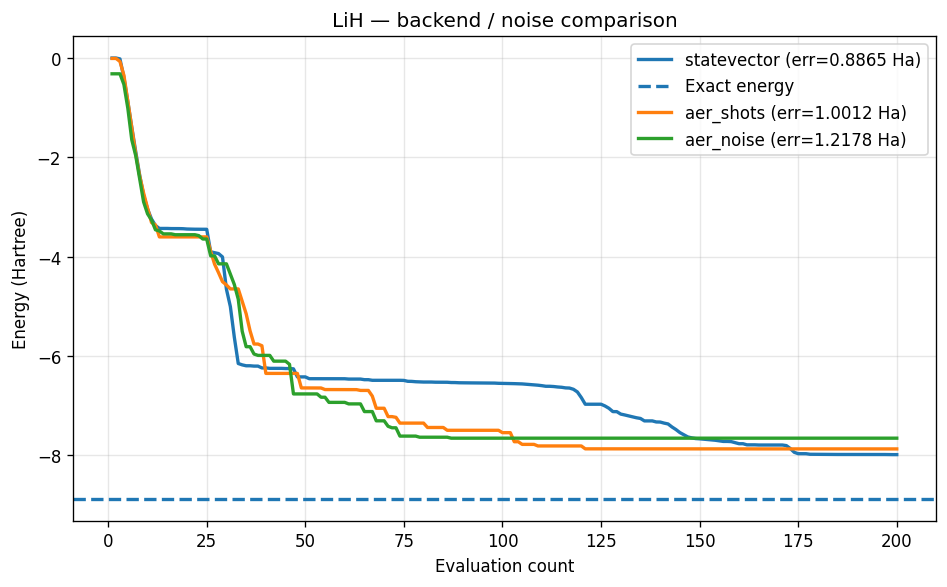

In [8]:
noise_results = {
    mode: run_vqe(
        bundle,
        ansatz_kind="hardware_efficient",
        optimizer_name="COBYLA",
        backend_mode=mode,
        reps=1,
        seed=CONFIG["random_seed"],
        show_progress=True,
        label=mode,
    )
    for mode in ["statevector", "aer_shots", "aer_noise"]
}

plot_overlay(
    noise_results,
    title=f"{CONFIG['molecule_name']} — backend / noise comparison",
)